In [1]:
import sys, classy, os
print('PYTHON ', sys.executable)
print('CLASSY ', classy.__file__)

PYTHON  /Users/chakkritk/myUniverse/research/research_tools/class_quintom/.qtm/bin/python
CLASSY  /Users/chakkritk/myUniverse/research/research_tools/class_quintom/.qtm/lib/python3.14/site-packages/classy.cpython-314-darwin.so


In [2]:
import subprocess, shlex
so = classy.__file__
print("has Phantom string?:", subprocess.run(shlex.split(f"strings -a {so}"), capture_output=True, text=True).stdout.find("Phantom Field") != -1)

has Phantom string?: True


In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy import Class

In [2]:
#Quintom model
qtm = Class()
qtm.set({'h': 0.678668,
            'omega_b': 0.02227716,
            'N_ur': 2.046,
            'YHe' : 0.245352,
            'omega_cdm': 0.1184293,
            # 'f_bm' : 0.1583,
            'Omega_Lambda': 0.0,
            'Omega_fld': 0.0,
            'Omega_scf': -1,
            'scf_parameters': '1., 0.0, 0.0, 0.0, 10.0, 0.0',
            'attractor_ic_scf': 'yes',
            'delta_pht': 0.1,
            'Omega_pht': 0.001,
            # 'sigma_prime_pht': 1.0e-5,
            'input_verbose': 1,
            'background_verbose': 3
            })

qtm.compute()

Reading input parameters
Computing unknown input parameter 'sigma_prime_pht' using input parameter 'Omega_pht'
 -> matched budget equations by adjusting Omega_scf = 0.69443
 -> matched budget equations by adjusting Omega_scf = 0.69443
 -> matched budget equations by adjusting Omega_scf = 2.08965e+15
 -> matched budget equations by adjusting Omega_scf = 5.22411e+14
 -> matched budget equations by adjusting Omega_scf = 0.69443
 -> matched budget equations by adjusting Omega_scf = 1.30603e+14
 -> found 'sigma_prime_pht = 0.00000000000000000000e+00'
 -> matched budget equations by adjusting Omega_scf = 0.69443
Running CLASS version v3.3.1
Computing background
 No attractor IC for lambda = 1.000e+00 ! 
 Chose ndf15 as generic_evolver
 -> age = 0.021760 Gyr
 -> conformal age = 128.719194 Mpc
 -> N_eff = 2.046 (summed over all species that are non-relativistic at early times) 
    Scalar field details:
     -> Omega_scf = 0.902467, wished 0.69443
     -> parameters: [lambda, alpha, A, B] = 
 

In [5]:
qtm.empty()
# qtm.struct_cleanup()

In [3]:
bg_qtm = qtm.get_background()

In [6]:
bg_qtm.keys()

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)p_scf', '(.)p_prime_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", '(.)rho_pht', '(.)p_pht', '(.)p_prime_pht', 'sigma_pht', "sigma'_pht", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])

In [4]:
z = bg_qtm['z']
a = 1/(1+z)
rho_b = bg_qtm['(.)rho_b']
rho_cdm = bg_qtm['(.)rho_cdm']
rho_scf = bg_qtm['(.)rho_scf']
rho_pht = bg_qtm['(.)rho_pht']
rho_c = bg_qtm['(.)rho_crit']
Orad = (bg_qtm['(.)rho_ur'] + bg_qtm['(.)rho_g'])/rho_c
Ob = rho_b/rho_c
Ocdm = rho_cdm/rho_c
Oscf = rho_scf/rho_c
Opht = rho_pht/rho_c
Ode = Opht + Oscf
Otot = Ob + Ocdm + Ode + Orad
qtm.empty()  # free memory
qtm.struct_cleanup()  # free memory

KeyError: '(.)rho_pht'

In [ ]:
Ode

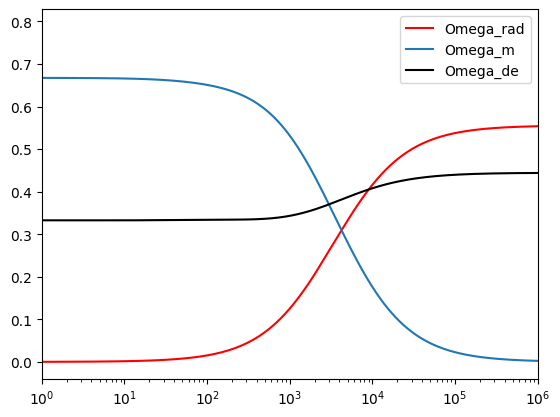

In [8]:
# plt.semilogx(1+z, Ob, label='Omega_b')
plt.semilogx(1+z, Orad, label='Omega_rad', color='r')
plt.semilogx(1+z, Ocdm + Ob, label='Omega_m')
plt.semilogx(1+z, Ode, label='Omega_de', color='k')
plt.legend()
plt.xlim(1, 1e6)
plt.show()

In [ ]:
namelist = ['lum. dist.','comov. dist.','ang.diam.dist.']
colours = ['b','g','r']
for name in namelist:
    idx = namelist.index(name)
    plt.loglog(baLCDM['z'],fLCDM*baLCDM[name],colours[idx]+'-')
plt.legend(namelist,loc='upper left')
for name in namelist:
    idx = namelist.index(name)
    plt.loglog(baCDM['z'],fCDM*baCDM[name],colours[idx]+'--')
plt.xlim([0.07, 10])
plt.ylim([0.08, 20])

plt.xlabel(r"$z$")
plt.ylabel(r"$\mathrm{Distance}\times H_0$")
plt.tight_layout()
plt.savefig('distances.pdf')